In [71]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [72]:
df = pd.read_excel("glass.xlsx", sheet_name="glass")
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [73]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [74]:
df.shape

(214, 10)

In [75]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [76]:
df.duplicated().sum()

np.int64(1)

In [77]:
df.drop_duplicates(inplace=True,ignore_index=True) # remove the duplicate

In [78]:
df.duplicated().sum()

np.int64(0)

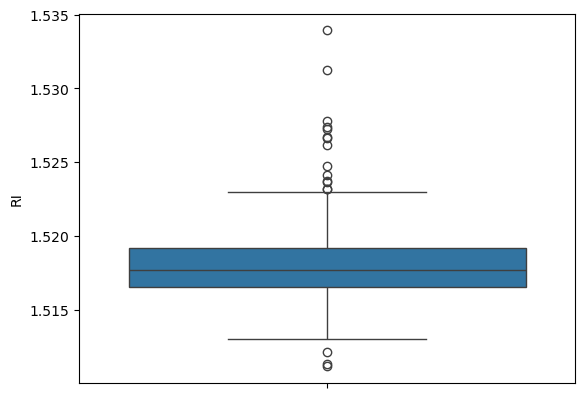

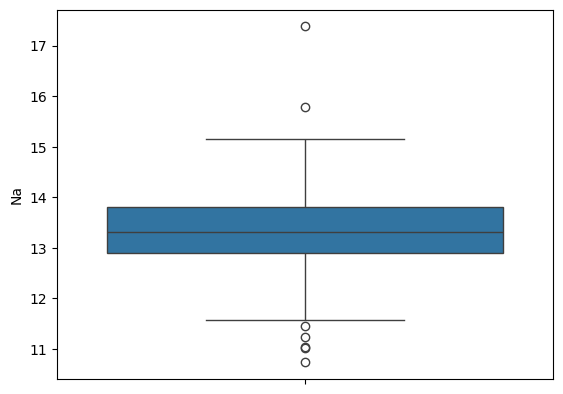

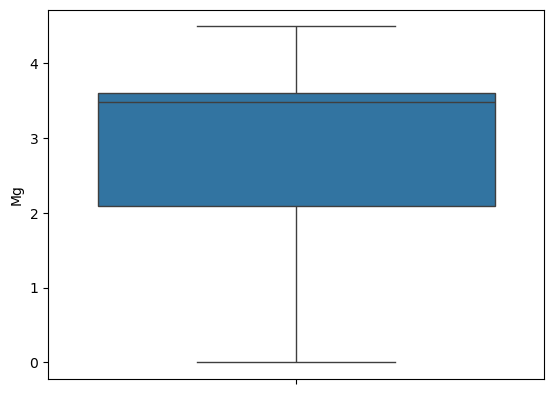

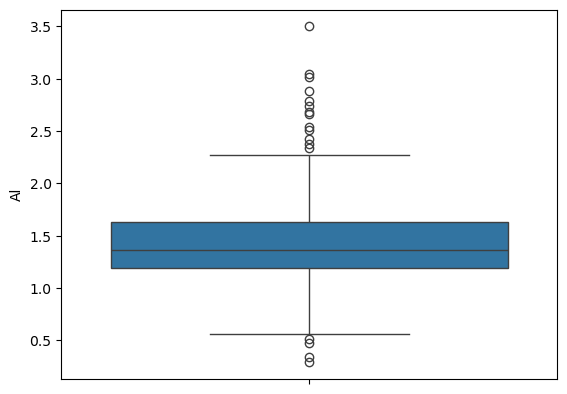

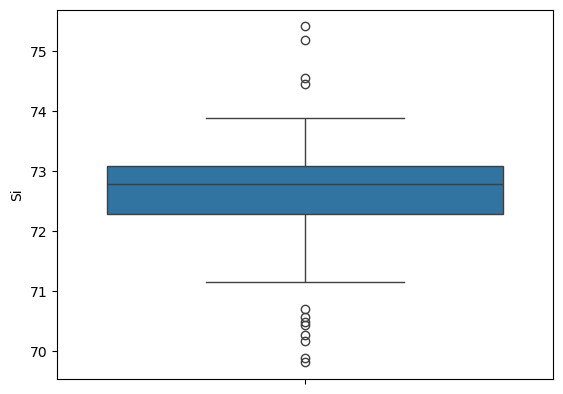

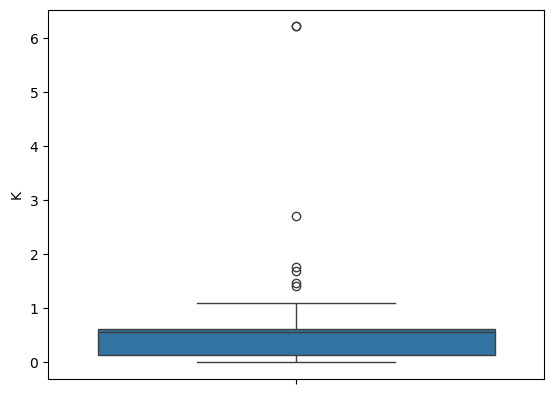

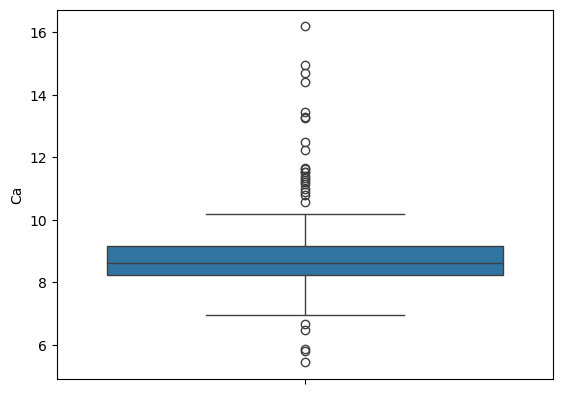

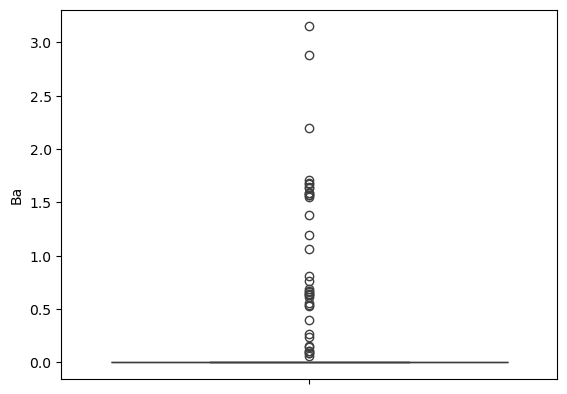

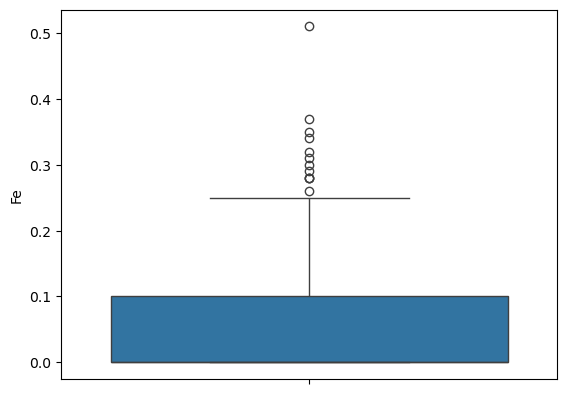

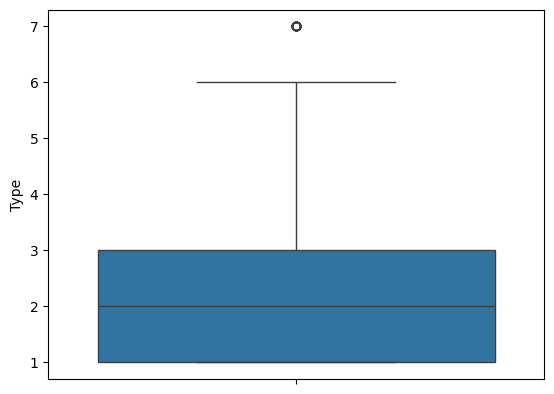

In [79]:
for col in df.columns:
    sns.boxplot(data=df,y=col)
    plt.show()

In [80]:
#### outlier capping

def outlier_capping(df,column):

    Q1= df[column].quantile(0.25)

    Q3= df[column].quantile(0.75)

    IQR= Q3-Q1

    lower_extreme= Q1-1.5*IQR

    upper_extreme= Q3+ 1.5*IQR

    df[column]= df[column].apply(lambda x:lower_extreme if x< lower_extreme else upper_extreme if x>upper_extreme else x)

for col in df.select_dtypes(include=['int','float']).columns:

    outlier_capping(df,col)

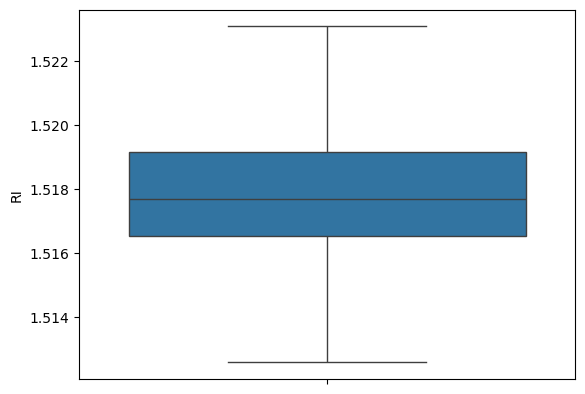

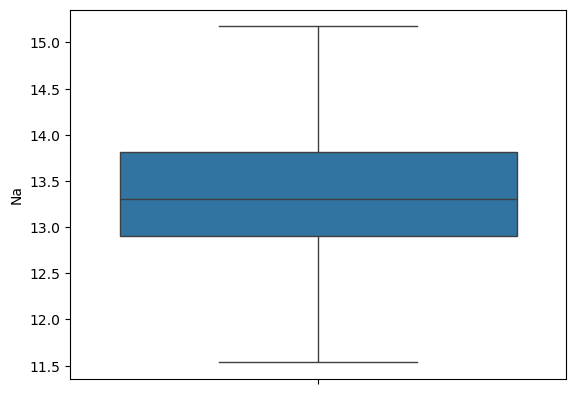

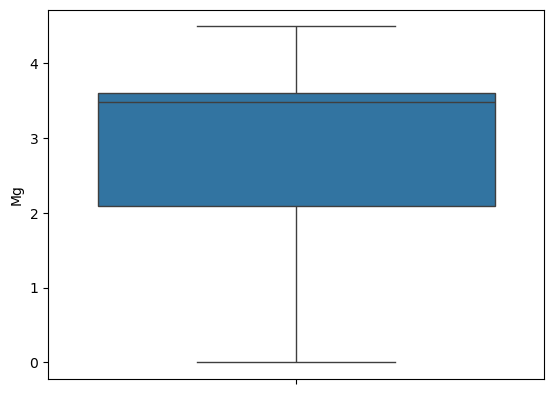

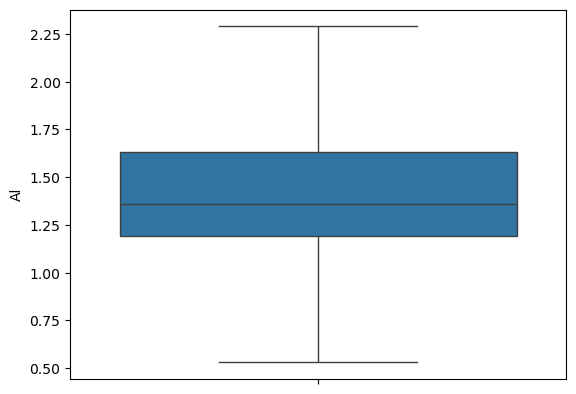

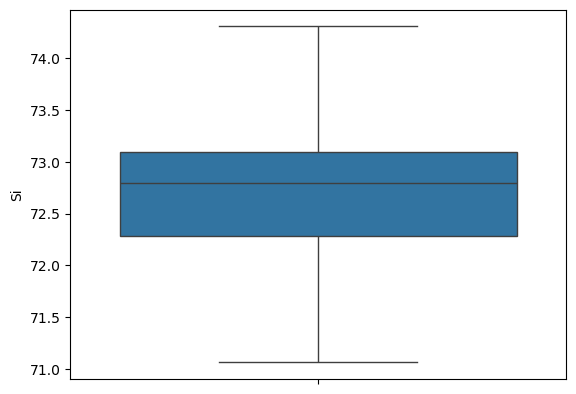

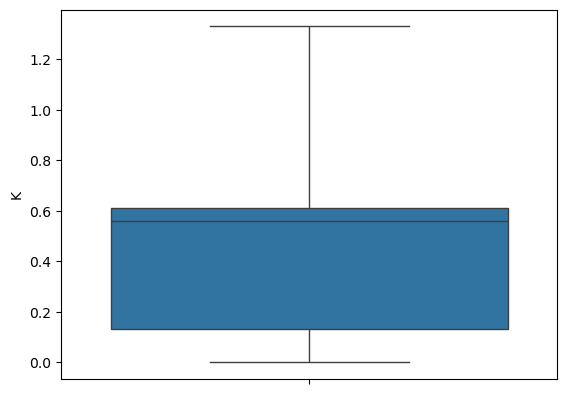

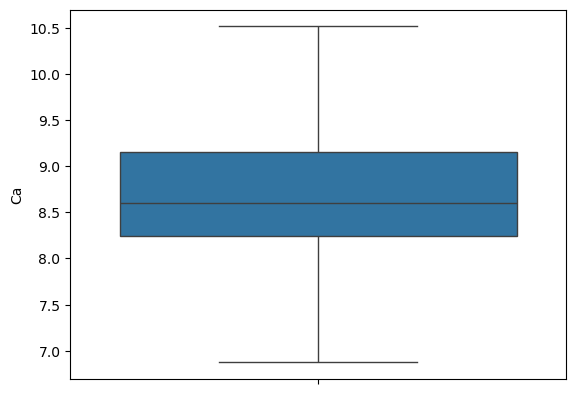

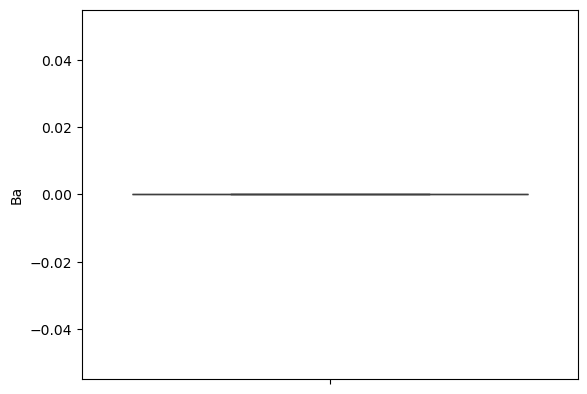

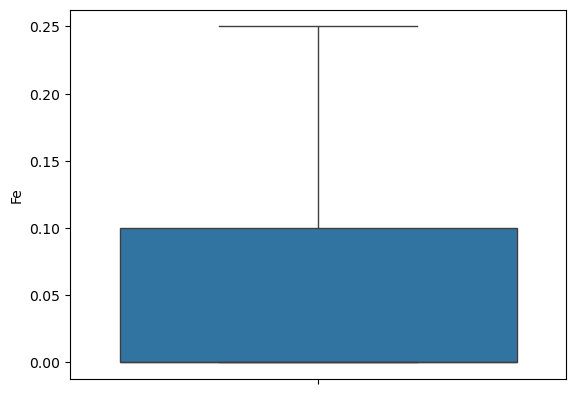

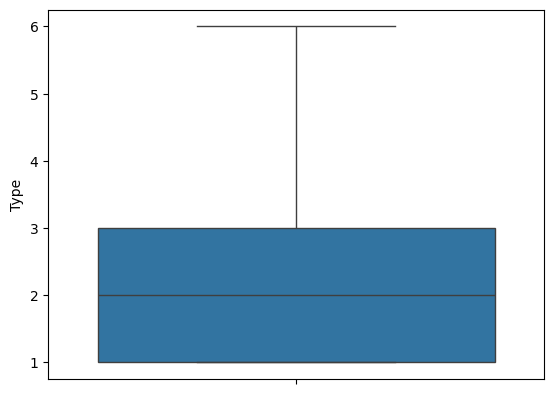

In [81]:
for col in df.columns:
    sns.boxplot(data=df,y=col)
    plt.show()

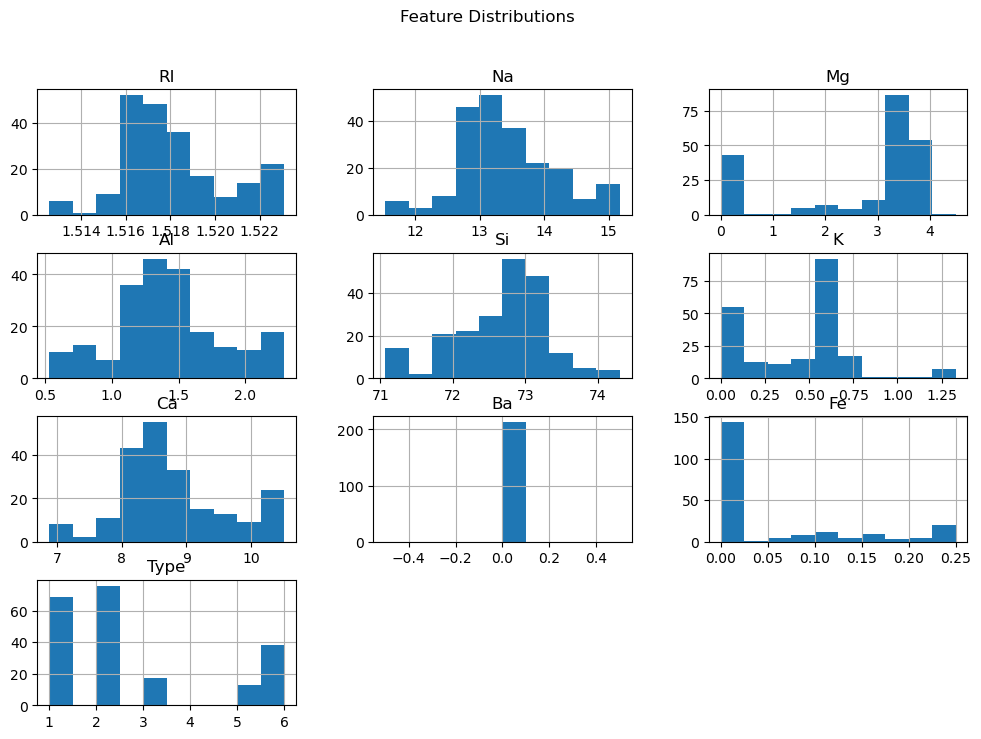

In [83]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure all columns are numeric
df = df.apply(pd.to_numeric, errors='coerce')

# Plot histograms
df.hist(figsize=(12, 8))
plt.suptitle("Feature Distributions")
plt.show()

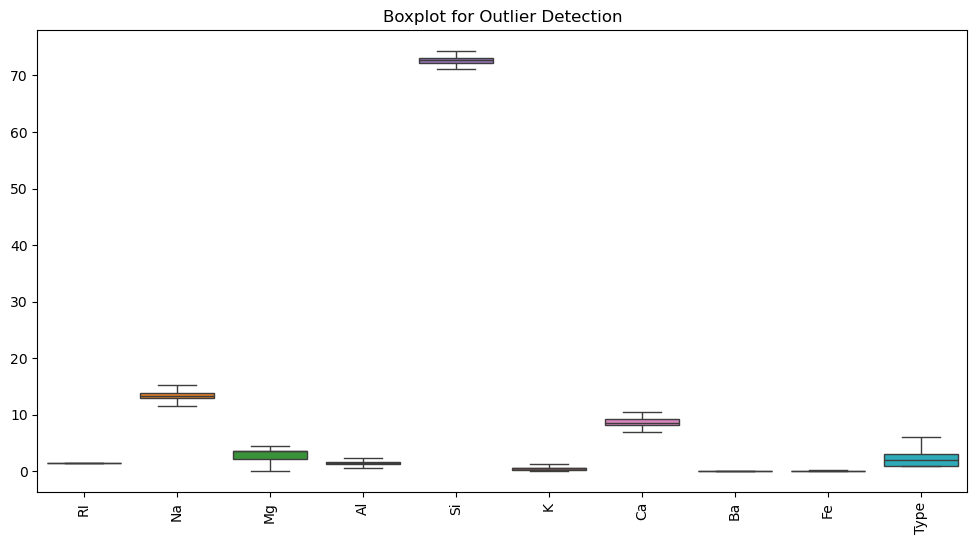

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.boxplot(data=df)
plt.title("Boxplot for Outlier Detection")
plt.xticks(rotation=90)
plt.show()

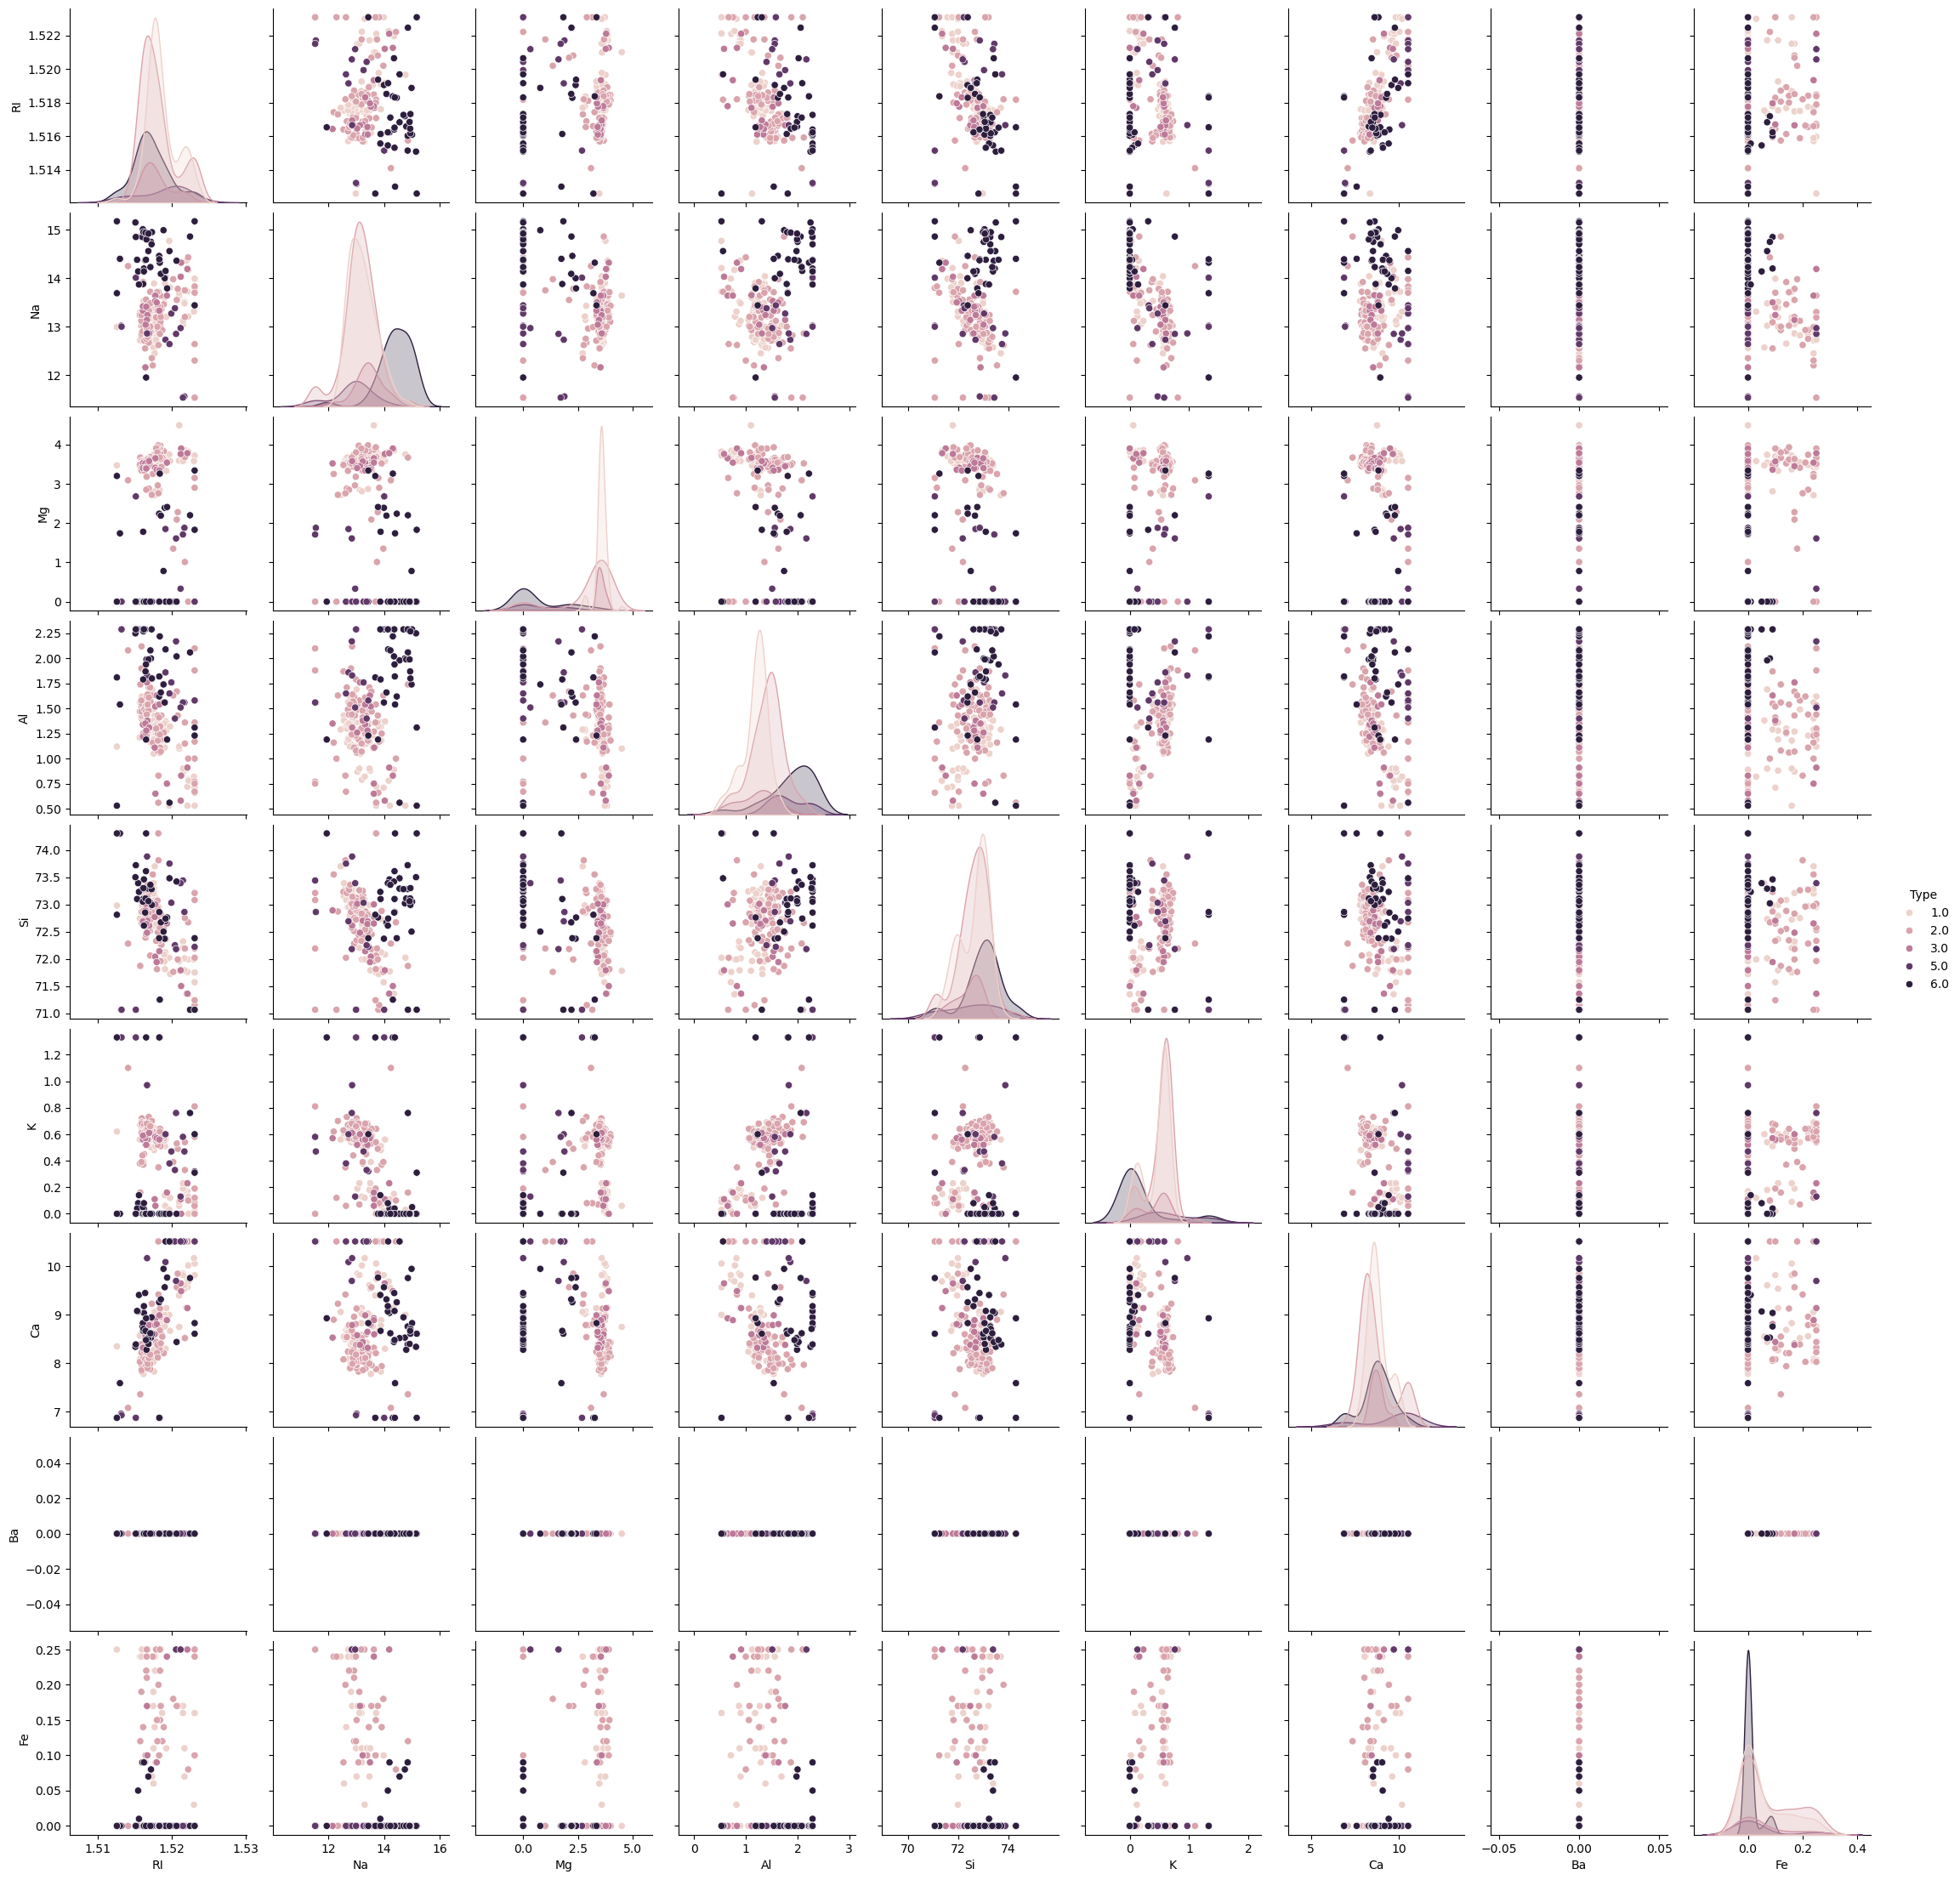

In [85]:
sns.pairplot(df, hue="Type")
plt.show()

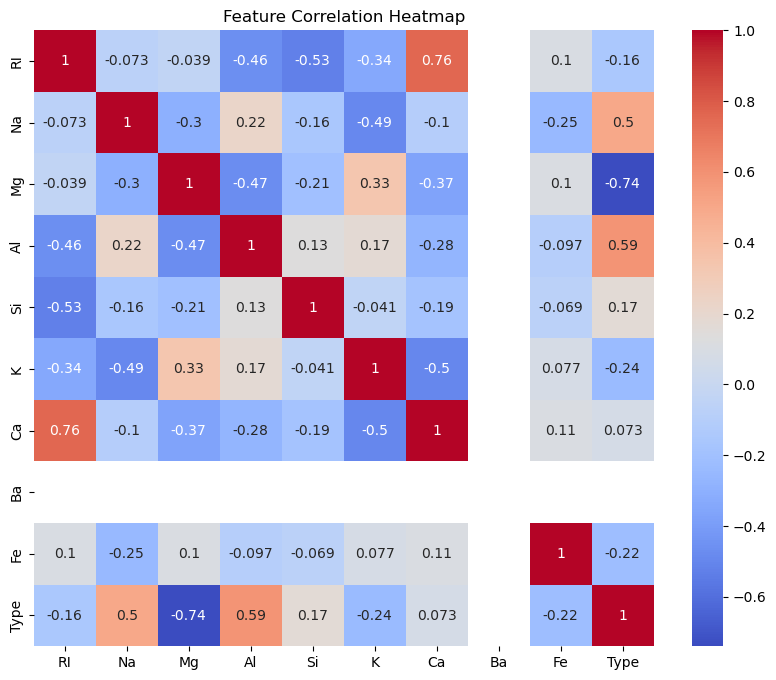

In [86]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

In [48]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [ ]:
X = df.drop("Type", axis=1)
y = df["Type"]

In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [40]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(X_train.shape)
print(X_test.shape)

(170, 9)
(43, 9)


In [49]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(170, 9)
(43, 9)


In [50]:
### Random Forest
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Random Forest Accuracy:", accuracy)

Random Forest Accuracy: 0.7674418604651163


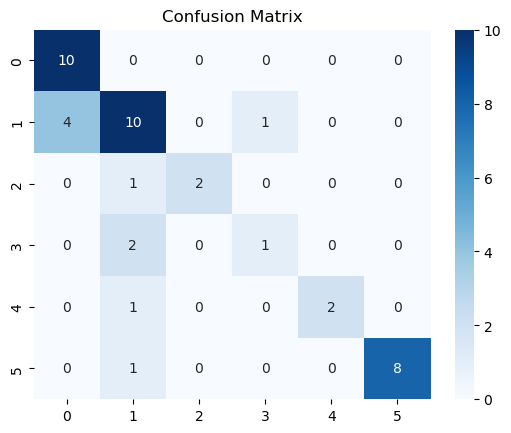

In [51]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

In [46]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.71      1.00      0.83        10
           2       0.67      0.67      0.67        15
           3       1.00      0.67      0.80         3
           5       0.50      0.33      0.40         3
           6       1.00      0.67      0.80         3
           7       1.00      0.89      0.94         9

    accuracy                           0.77        43
   macro avg       0.81      0.70      0.74        43
weighted avg       0.78      0.77      0.76        43



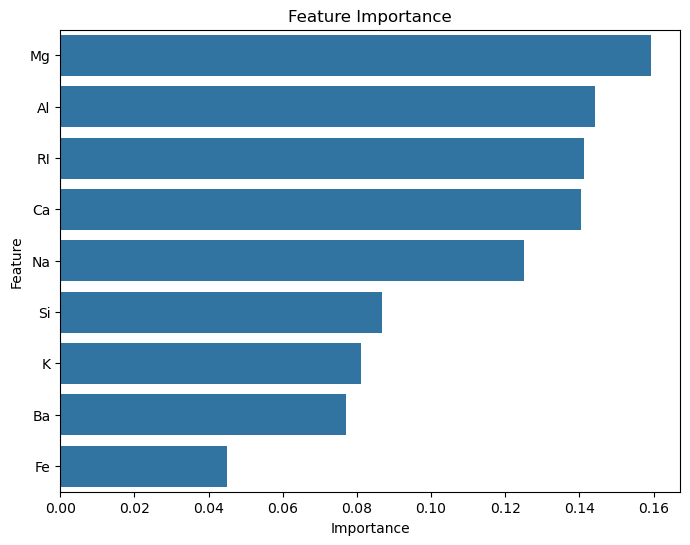

In [54]:
importances = rf.feature_importances_
features = X.columns
importance_df = pd.DataFrame({
    "Feature":features,
    "Importance":importances
})
importance_df = importance_df.sort_values(by="Importance", ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x="Importance", y="Feature", data=importance_df)
plt.title("Feature Importance")
plt.show()

In [41]:
### Bagging Method
from sklearn.ensemble import BaggingClassifier
bagging = BaggingClassifier(
    estimator=RandomForestClassifier(),
    n_estimators=50,
    random_state=42
)
bagging.fit(X_train, y_train)
bag_pred = bagging.predict(X_test)
print("Bagging Accuracy:", accuracy_score(y_test, bag_pred))

Bagging Accuracy: 0.7674418604651163


In [42]:
### Boosting Method
from sklearn.ensemble import AdaBoostClassifier
boost = AdaBoostClassifier(
    n_estimators=50,
    random_state=42
)
boost.fit(X_train, y_train)
boost_pred = boost.predict(X_test)
print("Boosting Accuracy:", accuracy_score(y_test, boost_pred))

Boosting Accuracy: 0.6046511627906976


In [56]:
###compare the results
results = pd.DataFrame({
    "Model":["Random Forest","Bagging","Boosting"],
    "Accuracy":[
        accuracy_score(y_test,y_pred),
        accuracy_score(y_test,bag_pred),
        accuracy_score(y_test,boost_pred)
    ]
})
results

,Model,Accuracy
0,Random Forest,0.767442
1,Bagging,0.767442
2,Boosting,0.604651
